# Prerequistes

In [48]:
%pip install qiskit qiskit-aer pylatexenc


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Generalised Amplitude Amplification

### Grover's Algorithm Analysis: Target = $|101\rangle$

Optimal iterations applied: 2


#### 1. Circuit Visualisation

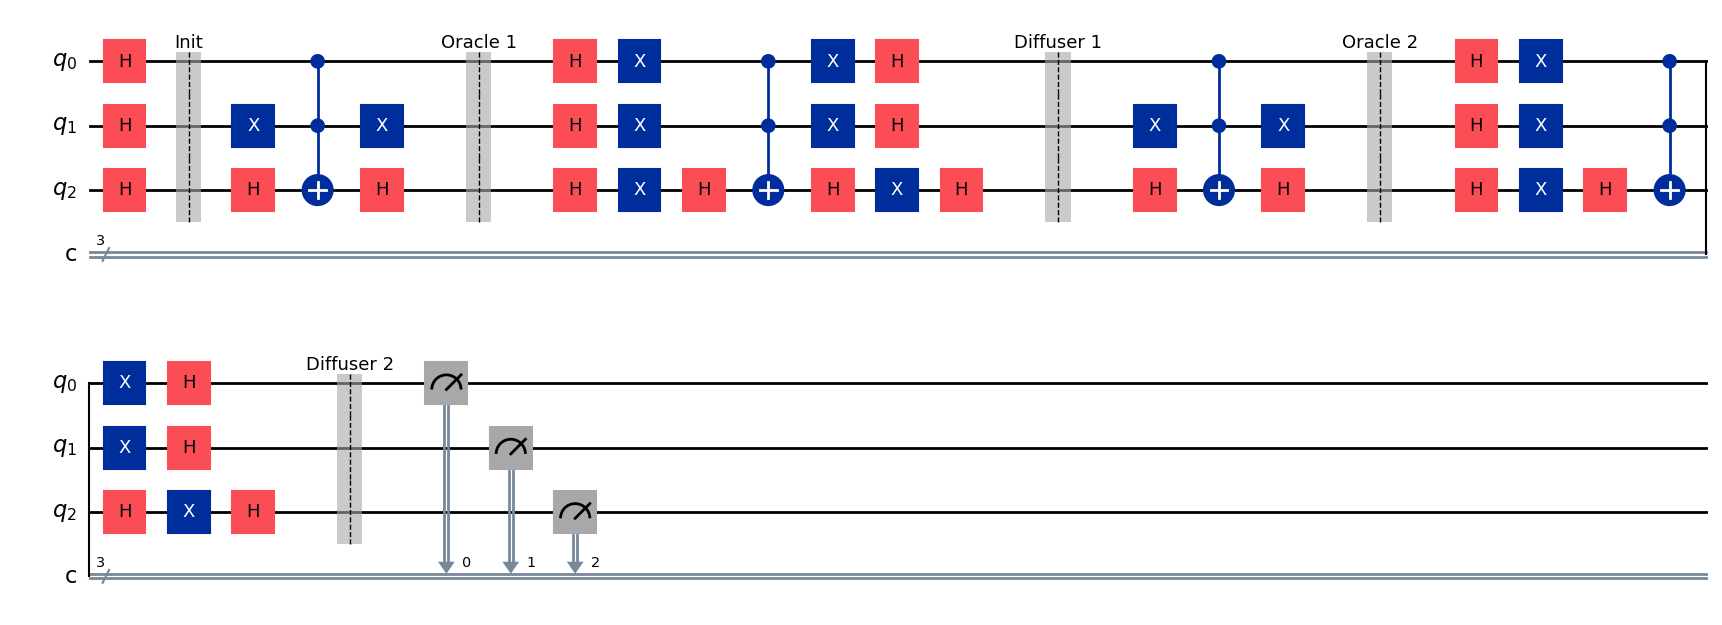

#### 2. Unitary Evolution

The 8x8 unitary matrix describing the full circuit:


<IPython.core.display.Latex object>

#### 3. Quantum State Representation

Exact Statevector prior to measurement:


<IPython.core.display.Latex object>


Final DensityMatrix prior to measurement:


<IPython.core.display.Latex object>

#### 4. State Visualisation

State prior to measurement (Bloch Spheres):


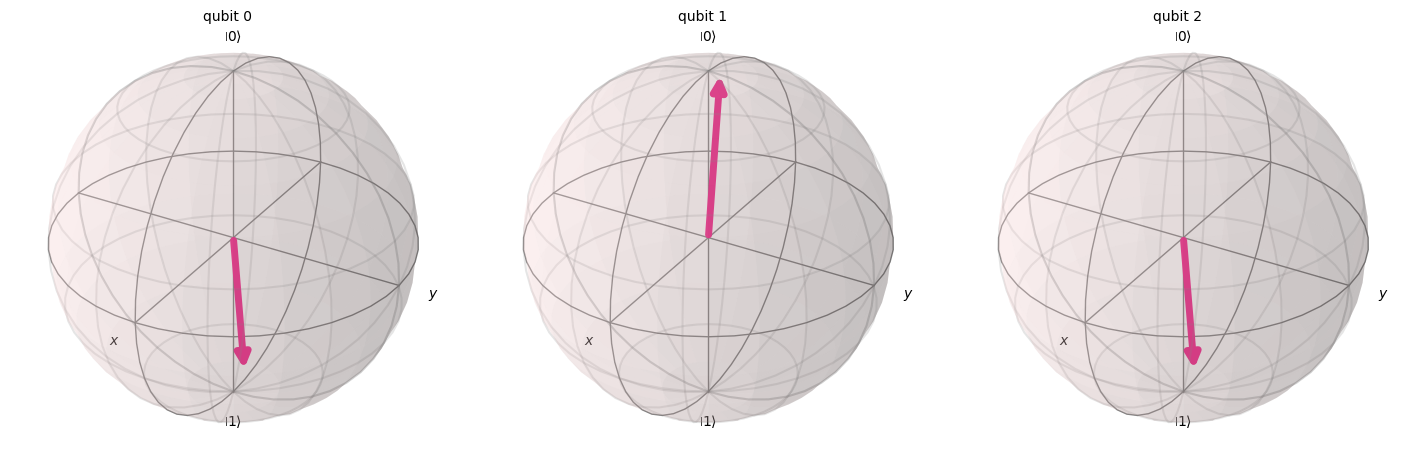


State prior to measurement (Q-Sphere):


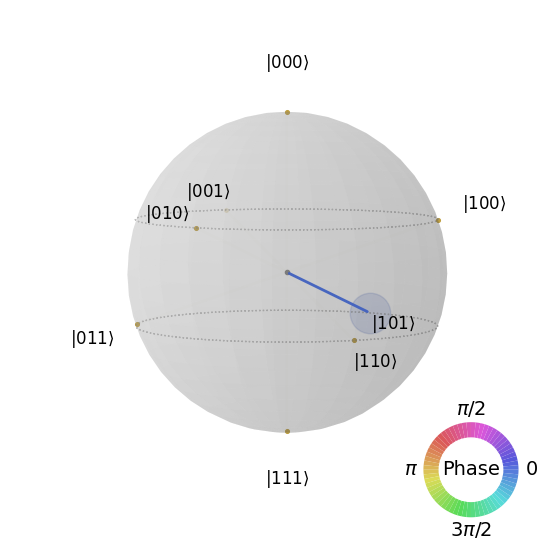

#### 5. Measurement Analysis

Raw measurement counts: {'001': 8, '110': 6, '100': 11, '011': 6, '111': 11, '000': 3, '010': 6, '101': 973}


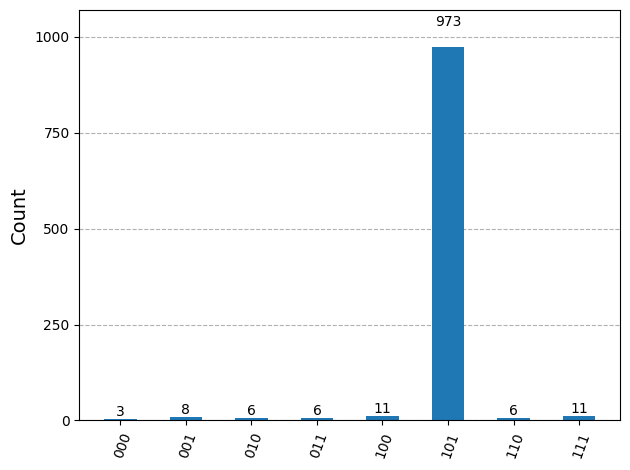

#### 6. Verification

Success: The algorithm correctly identified the target state '101'.
Success Probability: 95.02%


In [60]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, array_to_latex
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
target_string = "101"
n = len(target_string)
# Calculate optimal number of Grover iterations: (pi/4) * sqrt(N)
optimal_iterations = int(np.round((np.pi / 4) * np.sqrt(2**n)))

# 1. Set up Registers & Circuit
qr = QuantumRegister(n, name="q")
cr = ClassicalRegister(n, name="c")
qc = QuantumCircuit(qr, cr)

# 2. Initialisation (Equal Superposition)
qc.h(qr)
qc.barrier(label="Init")

# ==========================================
# GROVER ITERATIONS
# ==========================================
for step in range(optimal_iterations):
    # --- ORACLE ---
    # Reverse string to match Qiskit's little-endian ordering (q_0 is rightmost)
    reversed_target = target_string[::-1]
    
    # Flip qubits where target bit is '0'
    for i in range(n):
        if reversed_target[i] == '0':
            qc.x(qr[i])
            
    # Multi-controlled Z (MCZ) via H - MCX - H
    qc.h(qr[n-1])
    qc.mcx(list(range(n-1)), qr[n-1])
    qc.h(qr[n-1])
    
    # Undo X gates
    for i in range(n):
        if reversed_target[i] == '0':
            qc.x(qr[i])
    qc.barrier(label=f"Oracle {step+1}")
    
    # --- DIFFUSER (Inversion about Mean) ---
    qc.h(qr)
    qc.x(qr)
    
    # MCZ via H - MCX - H
    qc.h(qr[n-1])
    qc.mcx(list(range(n-1)), qr[n-1])
    qc.h(qr[n-1])
    
    qc.x(qr)
    qc.h(qr)
    qc.barrier(label=f"Diffuser {step+1}")

# ==========================================
# EXTRACT EXACT MATH BEFORE MEASUREMENT
# ==========================================
unitary = Operator(qc)
final_state = Statevector(qc)
final_density = DensityMatrix(qc)

# 3. Measurement
qc.measure(qr, cr)

# 4. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"### Grover's Algorithm Analysis: Target = $|{target_string}\\rangle$"))
print(f"Optimal iterations applied: {optimal_iterations}")

display(Markdown("#### 1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("#### 2. Unitary Evolution"))
# Guardrail: Suppress matrix printout for n > 3 to prevent Jupyter crashes
if n <= 3:
    print(f"The {2**n}x{2**n} unitary matrix describing the full circuit:")
    display(array_to_latex(unitary.data, prefix="U_{Grover} = ", max_size=16))
else:
    print(f"Unitary matrix omitted: {n} qubits results in a matrix too large for clean display.")

display(Markdown("#### 3. Quantum State Representation"))
print("Exact Statevector prior to measurement:")
display(final_state.draw('latex'))

print("\nFinal DensityMatrix prior to measurement:")
display(final_density.draw('latex'))

display(Markdown("#### 4. State Visualisation"))
print("State prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(final_state))

print("\nState prior to measurement (Q-Sphere):")
# The Q-sphere is particularly useful here as it will show a massive amplitude 
# concentrated on the target state, with minimal amplitudes elsewhere.
display(plot_state_qsphere(final_state))

display(Markdown("#### 5. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))

# 6. Final Verification Logic
display(Markdown("#### 6. Verification"))
measured_bitstring = max(counts, key=counts.get)
success_probability = counts[measured_bitstring] / 1024

if measured_bitstring == target_string:
    print(f"Success: The algorithm correctly identified the target state '{target_string}'.")
    print(f"Success Probability: {success_probability * 100:.2f}%")
else:
    print(f"Error: The algorithm identified '{measured_bitstring}' instead of '{target_string}'.")